In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('data/dataset_Facebook.csv', sep=';')

# Display shape, info, and describe output
print('Dataset Shape:')
display(df.shape)

print('\nDataset Info:')
df.info()

print('\nDataset Description:')
display(df.describe())

Dataset Shape:


(500, 19)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float6

,Page total likes,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
count,500.000000,500.000000,500.000000,500.000000,500.000000,499.000000,500.00000,5.000000e+02,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,500.00000,499.000000,496.000000,500.000000
mean,123194.176000,1.880000,7.038000,4.150000,7.840000,0.278557,13903.36000,2.958595e+04,920.344000,798.772000,1415.130000,1.676638e+04,6585.488000,609.986000,7.48200,177.945892,27.266129,212.120000
std,16272.813214,0.852675,3.307936,2.030701,4.368589,0.448739,22740.78789,7.680325e+04,985.016636,882.505013,2000.594118,5.979102e+04,7682.009405,612.725618,21.18091,323.398742,42.613292,380.233118
min,81370.000000,1.000000,1.000000,1.000000,1.000000,0.000000,238.00000,5.700000e+02,9.000000,9.000000,9.000000,5.670000e+02,236.000000,9.000000,0.00000,0.000000,0.000000,0.000000
25%,112676.000000,1.000000,4.000000,2.000000,3.000000,0.000000,3315.00000,5.694750e+03,393.750000,332.500000,509.250000,3.969750e+03,2181.500000,291.000000,1.00000,56.500000,10.000000,71.000000
50%,129600.000000,2.000000,7.000000,4.000000,9.000000,0.000000,5281.00000,9.051000e+03,625.500000,551.500000,851.000000,6.255500e+03,3417.000000,412.000000,3.00000,101.000000,19.000000,123.500000
75%,136393.000000,3.000000,10.000000,6.000000,11.000000,1.000000,13168.00000,2.208550e+04,1062.000000,955.500000,1463.000000,1.486050e+04,7989.000000,656.250000,7.00000,187.500000,32.250000,228.500000
max,139441.000000,3.000000,12.000000,7.000000,23.000000,1.000000,180480.00000,1.110282e+06,11452.000000,11328.000000,19779.000000,1.107833e+06,51456.000000,4376.000000,372.00000,5172.000000,790.000000,6334.000000


### Handling Missing Values

Based on the `.info()` output, the following columns have missing values:
- `Paid`: 1 missing value
- `like`: 1 missing value
- `share`: 4 missing values

Since the percentage of missing values in these columns is very low (well below 10%), dropping the entire column is not necessary. Dropping rows could lead to loss of other valuable data. Therefore, I will impute the missing values.

For `Paid`, `like`, and `share`, which are numeric columns, I will use the **median** for imputation. The median is chosen over the mean because it is less sensitive to outliers, which can distort the mean. `Paid` often acts as a binary indicator (0 or 1), and the median would likely preserve the distribution better than the mean in such a case.

In [2]:
# Impute missing values for 'Paid' with its median
df['Paid'] = df['Paid'].fillna(df['Paid'].median())

# Impute missing values for 'like' with its median
df['like'] = df['like'].fillna(df['like'].median())

# Impute missing values for 'share' with its median
df['share'] = df['share'].fillna(df['share'].median())

# Verify that there are no more missing values in these columns
print("Missing values after imputation:")
display(df[['Paid', 'like', 'share']].isnull().sum())

Missing values after imputation:


Paid     0
like     0
share    0
dtype: int64

### Outlier Detection and Handling (IQR Method)

I will detect outliers in the 'Lifetime Post Total Reach' and 'Lifetime Post Total Impressions' columns. These columns represent metrics that can often have a wide distribution and are prone to outliers. The IQR method will be used, where values falling below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` are considered outliers.

To handle these outliers, I will implement **capping**. This strategy replaces outlier values with the nearest non-outlier boundary (either `Q1` for lower outliers or `Q3` for upper outliers). Capping helps to reduce the effect of extreme values without removing valuable data points, which can be beneficial for downstream analysis.

Paid --> Numberic (DataType) --> Missing Value Stratergy(Filled with median)
The column has very few missing values and represents a binary/numeric feature. Median preserves the existing distribution without being affected by outliers.

Lifetime Post Consumers by Type --> Numberic (DataType) --> Filled with median
Engagement-related values are positively skewed with several extreme observations. Median provides a robust estimate compared to the mean.


### Reason for choosing median
- Preserves all observations.
- More robust than mean for skewed marketing metrics.
- Prevents unnecessary data loss.
- Suitable because the percentage of missing values is low.

In [3]:
import numpy as np

def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    print(f"Outliers in '{column}' capped. Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

# Apply outlier capping to selected numeric columns
columns_to_cap = ['Lifetime Post Total Reach', 'Lifetime Post Total Impressions']

for col in columns_to_cap:
    cap_outliers_iqr(df, col)

print("\nOutlier capping complete for the selected columns.")
# Display descriptive statistics after capping to observe changes
print("\nDescriptive statistics after outlier capping:")
display(df[columns_to_cap].describe())

Outliers in 'Lifetime Post Total Reach' capped. Lower bound: -11464.50, Upper bound: 27947.50
Outliers in 'Lifetime Post Total Impressions' capped. Lower bound: -18891.38, Upper bound: 46671.62

Outlier capping complete for the selected columns.

Descriptive statistics after outlier capping:


,Lifetime Post Total Reach,Lifetime Post Total Impressions
count,500.00000,500.000000
mean,9576.37100,16339.999000
std,9059.08552,15181.269524
min,238.00000,570.000000
25%,3315.00000,5694.750000
50%,5281.00000,9051.000000
75%,13168.00000,22085.500000
max,27947.50000,46671.625000


### Correcting Data Types and Removing Duplicate Rows

As noted in the initial data exploration, the `Category` column is currently stored as an integer (`int64`), but it logically represents discrete categories (1, 2, 3). Converting this to a `category` data type will make the data type consistent with its logical meaning and can also be more memory-efficient.

Finally, I will remove any duplicate rows from the entire dataset to ensure data integrity and avoid redundant entries. This helps in maintaining the uniqueness of observations.

In [4]:
# Convert 'Category' column to categorical type
df['Category'] = df['Category'].astype('category')
print("Data type of 'Category' column after conversion:")
display(df['Category'].dtype)

# Remove duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
rows_after_dropping_duplicates = df.shape[0]

print(f"\nInitial number of rows: {initial_rows}")
print(f"Number of rows after dropping duplicates: {rows_after_dropping_duplicates}")
print(f"Number of duplicate rows removed: {initial_rows - rows_after_dropping_duplicates}")

print("\nDataset info after data type correction and duplicate removal:")
df.info()

Data type of 'Category' column after conversion:


CategoricalDtype(categories=[1, 2, 3], ordered=False, categories_dtype=int64)


Initial number of rows: 500
Number of rows after dropping duplicates: 500
Number of duplicate rows removed: 0

Dataset info after data type correction and duplicate removal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype   
---  ------                                                               --------------  -----   
 0   Page total likes                                                     500 non-null    int64   
 1   Type                                                                 500 non-null    object  
 2   Category                                                             500 non-null    category
 3   Post Month                                                           500 non-null    int64   
 4   Post Weekday                                                         500 non-null    int64   
 5   Post Hour             

## Task 3: Load Cleaned Dataset into SQLite Database and SQL Querying

Now that the dataset is cleaned, I will load it into a local SQLite database. This allows for SQL-based querying and analysis, providing another perspective on the data.

I'll use `pandas.DataFrame.to_sql()` to easily transfer the DataFrame into a new SQLite table.

In [5]:
import sqlite3

# Create a SQLite database in memory (or specify a file path for a persistent database)
conn = sqlite3.connect(':memory:') # Using ':memory:' for an in-memory database

# Convert column names to be SQL-friendly (replace spaces with underscores, make lowercase)
df_sql = df.copy()
df_sql.columns = df_sql.columns.str.replace(' ', '_').str.lower()

# Load the DataFrame into a SQL table named 'facebook_posts'
# if_exists='replace' means it will overwrite the table if it already exists
df_sql.to_sql('facebook_posts', conn, if_exists='replace', index=False)

print("Cleaned DataFrame loaded into SQLite database 'facebook_posts' table.")

# Verify the table creation and schema
print("\nSchema of 'facebook_posts' table:")
query = "PRAGMA table_info(facebook_posts);"
cursor = conn.execute(query)
for row in cursor:
    print(row)


Cleaned DataFrame loaded into SQLite database 'facebook_posts' table.

Schema of 'facebook_posts' table:
(0, 'page_total_likes', 'INTEGER', 0, None, 0)
(1, 'type', 'TEXT', 0, None, 0)
(2, 'category', 'TEXT', 0, None, 0)
(3, 'post_month', 'INTEGER', 0, None, 0)
(4, 'post_weekday', 'INTEGER', 0, None, 0)
(5, 'post_hour', 'INTEGER', 0, None, 0)
(6, 'paid', 'REAL', 0, None, 0)
(7, 'lifetime_post_total_reach', 'REAL', 0, None, 0)
(8, 'lifetime_post_total_impressions', 'REAL', 0, None, 0)
(9, 'lifetime_engaged_users', 'INTEGER', 0, None, 0)
(10, 'lifetime_post_consumers', 'INTEGER', 0, None, 0)
(11, 'lifetime_post_consumptions', 'INTEGER', 0, None, 0)
(12, 'lifetime_post_impressions_by_people_who_have_liked_your_page', 'INTEGER', 0, None, 0)
(13, 'lifetime_post_reach_by_people_who_like_your_page', 'INTEGER', 0, None, 0)
(14, 'lifetime_people_who_have_liked_your_page_and_engaged_with_your_post', 'INTEGER', 0, None, 0)
(15, 'comment', 'INTEGER', 0, None, 0)
(16, 'like', 'REAL', 0, None, 0)
(17

### Executing SQL Queries

I will now execute several SQL queries against the `facebook_posts` table to gain insights into the data. Each query will be explained, and its results displayed.

In [6]:
# Helper function to execute SQL queries and display results
def run_query(query):
    return pd.read_sql_query(query, conn)

print("Helper function 'run_query' defined.")

Helper function 'run_query' defined.


#### Query 1: Top 5 Posts by Total Interactions

This query identifies the posts with the highest total interactions, which can include likes, comments, and shares. This helps understand what content resonates most with the audience.

In [7]:
query1 = """
SELECT
    type,
    category,
    post_month,
    post_weekday,
    post_hour,
    total_interactions
FROM
    facebook_posts
ORDER BY
    total_interactions DESC
LIMIT 5;
"""
print("Top 5 Posts by Total Interactions:")
display(run_query(query1))

Top 5 Posts by Total Interactions:


,type,category,post_month,post_weekday,post_hour,total_interactions
0,Photo,2,7,3,5,6334
1,Photo,3,4,1,14,2177
2,Photo,1,9,3,10,1974
3,Photo,3,2,1,13,1873
4,Photo,3,5,5,13,1806


#### Query 2: Average Likes, Shares, and Comments by Post Type

This query calculates the average number of likes, shares, and comments for each post type (e.g., Photo, Video, Status). This can reveal which types of content generally perform better across different engagement metrics.

In [8]:
query2 = """
SELECT
    type,
    AVG(like) AS avg_likes,
    AVG(share) AS avg_shares,
    AVG(comment) AS avg_comments,
    AVG(total_interactions) AS avg_total_interactions
FROM
    facebook_posts
GROUP BY
    type
ORDER BY
    avg_total_interactions DESC;
"""
print("Average Engagement Metrics by Post Type:")
display(run_query(query2))

Average Engagement Metrics by Post Type:


,type,avg_likes,avg_shares,avg_comments,avg_total_interactions
0,Video,231.428571,52.142857,12.285714,295.857143
1,Status,176.711111,31.422222,8.911111,217.044444
2,Photo,182.420188,27.082160,7.492958,216.579812
3,Link,73.318182,12.909091,2.818182,89.045455


#### Query 3: Monthly Average Total Interactions

This query calculates the average total interactions for posts each month. This can help identify trends or peak performance periods throughout the year.

In [9]:
query3 = """
SELECT
    post_month,
    AVG(total_interactions) AS avg_total_interactions_month
FROM
    facebook_posts
GROUP BY
    post_month
ORDER BY
    post_month;
"""
print("Monthly Average Total Interactions:")
display(run_query(query3))

Monthly Average Total Interactions:


,post_month,avg_total_interactions_month
0,1,160.600000
1,2,242.038462
2,3,97.055556
3,4,217.520000
4,5,256.297297
5,6,157.714286
6,7,328.500000
7,8,225.382353
8,9,278.500000
9,10,182.900000


In [10]:
query3 = """
SELECT
    post_month,
    AVG(total_interactions) AS avg_total_interactions_month
FROM
    facebook_posts
GROUP BY
    post_month
ORDER BY
    post_month;
"""
print("Monthly Average Total Interactions:")
display(run_query(query3))

Monthly Average Total Interactions:


,post_month,avg_total_interactions_month
0,1,160.600000
1,2,242.038462
2,3,97.055556
3,4,217.520000
4,5,256.297297
5,6,157.714286
6,7,328.500000
7,8,225.382353
8,9,278.500000
9,10,182.900000


In [11]:
print("Monthly Average Total Interactions:")
display(run_query(query3))

Monthly Average Total Interactions:


,post_month,avg_total_interactions_month
0,1,160.600000
1,2,242.038462
2,3,97.055556
3,4,217.520000
4,5,256.297297
5,6,157.714286
6,7,328.500000
7,8,225.382353
8,9,278.500000
9,10,182.900000


#### Query 4: Performance Comparison: Paid vs. Unpaid Posts

This query compares the average engagement metrics (likes, shares, comments, total interactions) between paid and unpaid posts. This helps understand the impact of advertising on post performance.

In [12]:
query4 = """
SELECT
    CASE
        WHEN paid = 1 THEN 'Paid'
        ELSE 'Unpaid'
    END AS post_status,
    AVG(like) AS avg_likes,
    AVG(share) AS avg_shares,
    AVG(comment) AS avg_comments,
    AVG(total_interactions) AS avg_total_interactions
FROM
    facebook_posts
GROUP BY
    post_status;
"""
print("Performance Comparison: Paid vs. Unpaid Posts:")
display(run_query(query4))

Performance Comparison: Paid vs. Unpaid Posts:


,post_status,avg_likes,avg_shares,avg_comments,avg_total_interactions
0,Paid,235.647482,32.503597,10.079137,278.230216
1,Unpaid,155.515235,25.157895,6.481994,186.664820


In [13]:
query4 = """
SELECT
    CASE
        WHEN paid = 1 THEN 'Paid'
        ELSE 'Unpaid'
    END AS post_status,
    AVG(like) AS avg_likes,
    AVG(share) AS avg_shares,
    AVG(comment) AS avg_comments,
    AVG(total_interactions) AS avg_total_interactions
FROM
    facebook_posts
GROUP BY
    post_status;
"""
print("Performance Comparison: Paid vs. Unpaid Posts:")
display(run_query(query4))

Performance Comparison: Paid vs. Unpaid Posts:


,post_status,avg_likes,avg_shares,avg_comments,avg_total_interactions
0,Paid,235.647482,32.503597,10.079137,278.230216
1,Unpaid,155.515235,25.157895,6.481994,186.664820


In [14]:
print("Performance Comparison: Paid vs. Unpaid Posts:")
display(run_query(query4))

Performance Comparison: Paid vs. Unpaid Posts:


,post_status,avg_likes,avg_shares,avg_comments,avg_total_interactions
0,Paid,235.647482,32.503597,10.079137,278.230216
1,Unpaid,155.515235,25.157895,6.481994,186.664820


#### Query 5: Top 3 Post Categories by Average Lifetime Engaged Users

This query identifies the top 3 post categories that lead to the highest average number of engaged users over the lifetime of the post. This can inform content strategy.

In [15]:
query5 = """
SELECT
    category,
    AVG(lifetime_engaged_users) AS avg_lifetime_engaged_users
FROM
    facebook_posts
GROUP BY
    category
ORDER BY
    avg_lifetime_engaged_users DESC
LIMIT 3;
"""
print("Top 3 Post Categories by Average Lifetime Engaged Users:")
display(run_query(query5))

Top 3 Post Categories by Average Lifetime Engaged Users:


,category,avg_lifetime_engaged_users
0,2,1138.361538
1,1,851.125581
2,3,833.503226


In [16]:
query5 = """
SELECT
    category,
    AVG(lifetime_engaged_users) AS avg_lifetime_engaged_users
FROM
    facebook_posts
GROUP BY
    category
ORDER BY
    avg_lifetime_engaged_users DESC
LIMIT 3;
"""
print("Top 3 Post Categories by Average Lifetime Engaged Users:")
display(run_query(query5))

Top 3 Post Categories by Average Lifetime Engaged Users:


,category,avg_lifetime_engaged_users
0,2,1138.361538
1,1,851.125581
2,3,833.503226


In [17]:
print("Top 3 Post Categories by Average Lifetime Engaged Users:")
display(run_query(query5))

Top 3 Post Categories by Average Lifetime Engaged Users:


,category,avg_lifetime_engaged_users
0,2,1138.361538
1,1,851.125581
2,3,833.503226


#### Query 6: Average Total Interactions by Post Hour

This query analyzes how the average total interactions vary by the hour a post was published. This can help determine optimal posting times for maximum engagement.

In [18]:
query6 = """
SELECT
    post_hour,
    AVG(total_interactions) AS avg_total_interactions
FROM
    facebook_posts
GROUP BY
    post_hour
ORDER BY
    post_hour;
"""
print("Average Total Interactions by Post Hour:")
display(run_query(query6))

Average Total Interactions by Post Hour:


,post_hour,avg_total_interactions
0,1,181.000000
1,2,191.102564
2,3,228.590476
3,4,168.085714
4,5,684.307692
5,6,157.125000
6,7,148.461538
7,8,90.250000
8,9,133.100000
9,10,250.910256


## Part 2: Visualizations

Now, let's create the required visualizations to further explore the cleaned dataset and derive insights.

### Saving Visualizations to a 'Plots Folder'

To organize the generated plots, a new subfolder named `Plots Folder` will be created within the existing `Part-1` directory. All subsequent visualization cells will be modified to save their respective plots into this folder before displaying them.

In [19]:
import os

plots_folder = os.path.join('Plots')

if not os.path.exists(plots_folder):
    os.makedirs(plots_folder)
    print(f"Created folder: {plots_folder}")
else:
    print(f"Folder already exists: {plots_folder}")

Folder already exists: Plots


### Visualization 1: Box Plot for Outlier Check

I will create box plots for 'Lifetime Post Total Reach' and 'Lifetime Post Total Impressions' to visually inspect the distributions and confirm the effect of outlier capping applied during the data cleaning phase. These plots should show that extreme outliers have been managed.

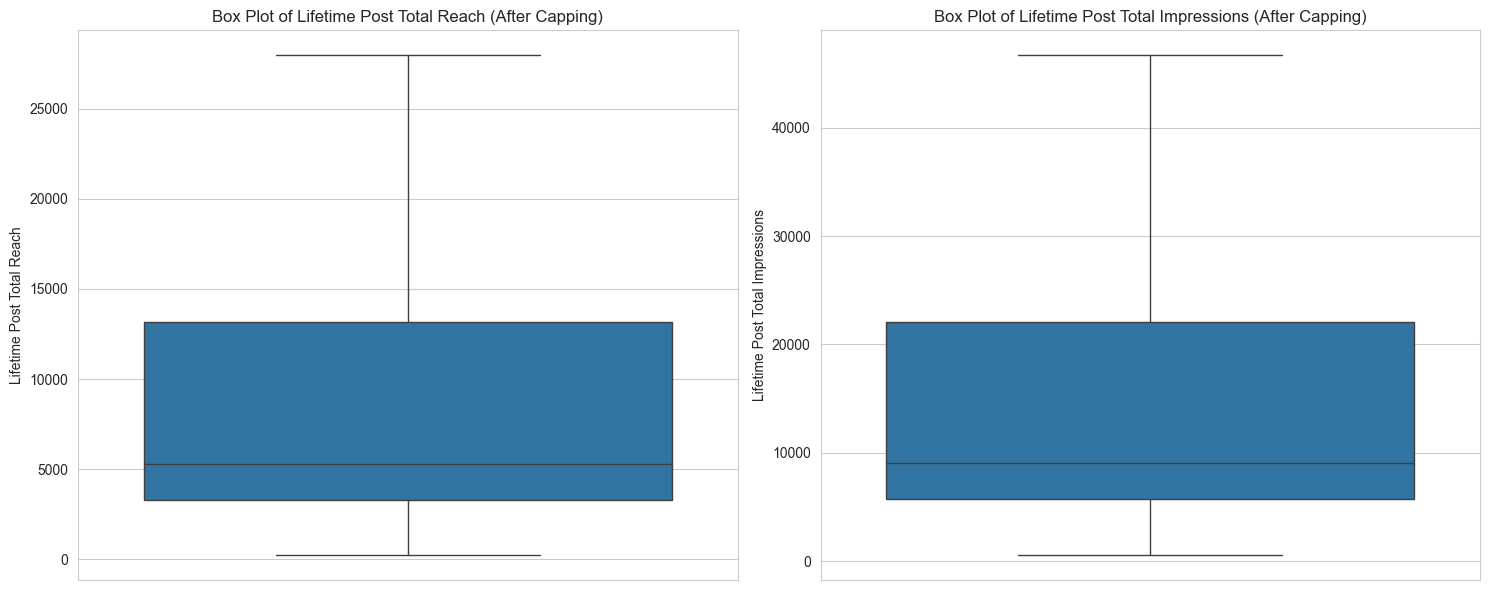

<Figure size 640x480 with 0 Axes>

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set the style for the plots
sns.set_style("whitegrid")

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Lifetime Post Total Reach'])
plt.title('Box Plot of Lifetime Post Total Reach (After Capping)')
plt.ylabel('Lifetime Post Total Reach')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Lifetime Post Total Impressions'])
plt.title('Box Plot of Lifetime Post Total Impressions (After Capping)')
plt.ylabel('Lifetime Post Total Impressions')

plt.tight_layout()
plt.savefig(os.path.join(plots_folder, 'box_plot_reach_impressions.png')) # Save the plot
plt.show()
plt.clf()

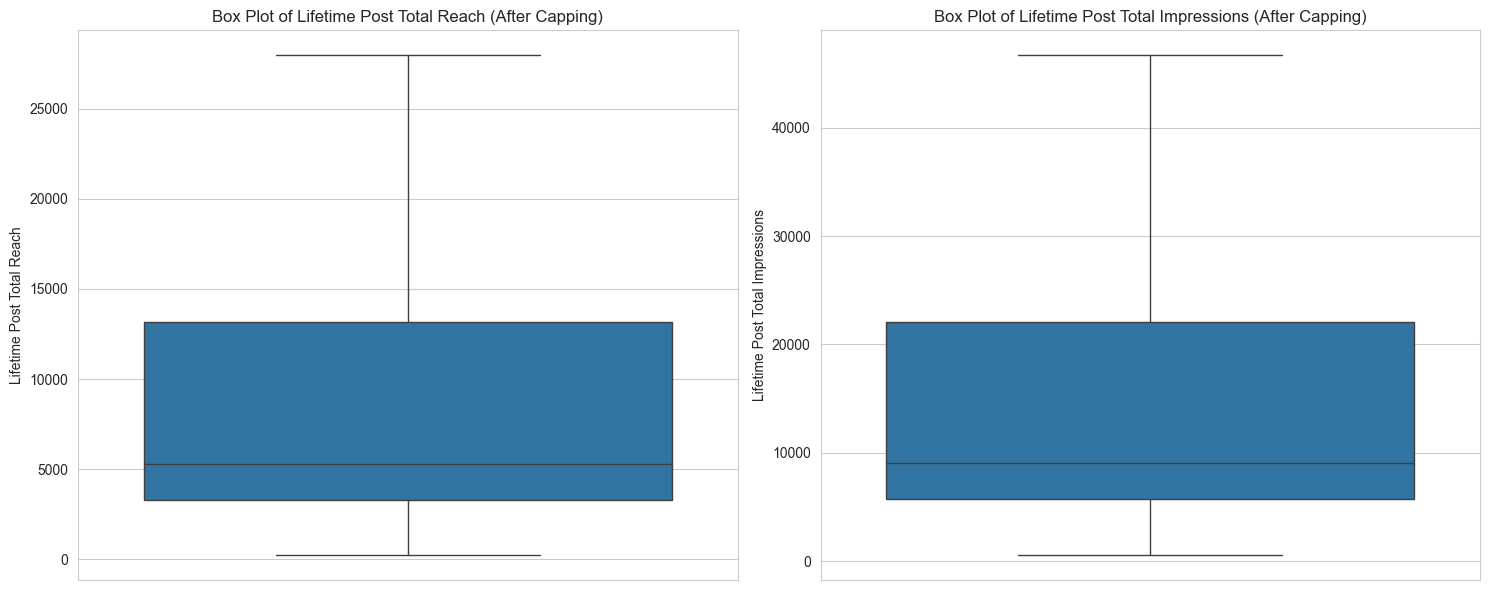

<Figure size 640x480 with 0 Axes>

In [21]:
# Re-executing the corrected box plot visualization
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set the style for the plots
sns.set_style("whitegrid")

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Lifetime Post Total Reach'])
plt.title('Box Plot of Lifetime Post Total Reach (After Capping)')
plt.ylabel('Lifetime Post Total Reach')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Lifetime Post Total Impressions'])
plt.title('Box Plot of Lifetime Post Total Impressions (After Capping)')
plt.ylabel('Lifetime Post Total Impressions')

plt.tight_layout()
plt.savefig(os.path.join(plots_folder, 'box_plot_reach_impressions_reexecute.png')) # Save the plot
plt.show()
plt.clf()

### Visualization 2: Histogram

I will create a histogram to visualize the distribution of 'Total Interactions'. This will help us understand the frequency of different interaction levels and identify common ranges of engagement.

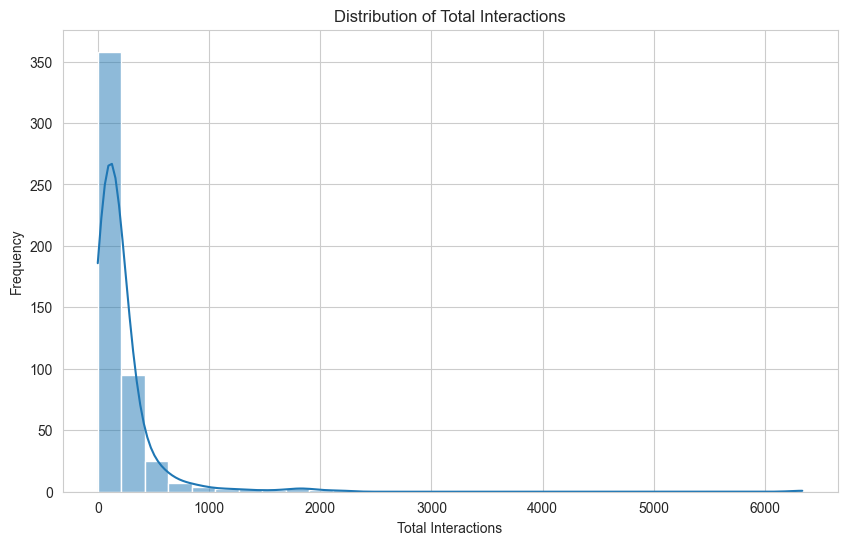

<Figure size 640x480 with 0 Axes>

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(10, 6))
sns.histplot(df['Total Interactions'], bins=30, kde=True)
plt.title('Distribution of Total Interactions')
plt.xlabel('Total Interactions')
plt.ylabel('Frequency')
plt.savefig(os.path.join(plots_folder, 'histogram_total_interactions.png')) # Save the plot
plt.show()
plt.clf()

### Visualization 3: Bar Chart from `value_counts()`

I will create a bar chart showing the frequency of each 'Type' of post. This will quickly illustrate which types of content are most prevalent in the dataset.

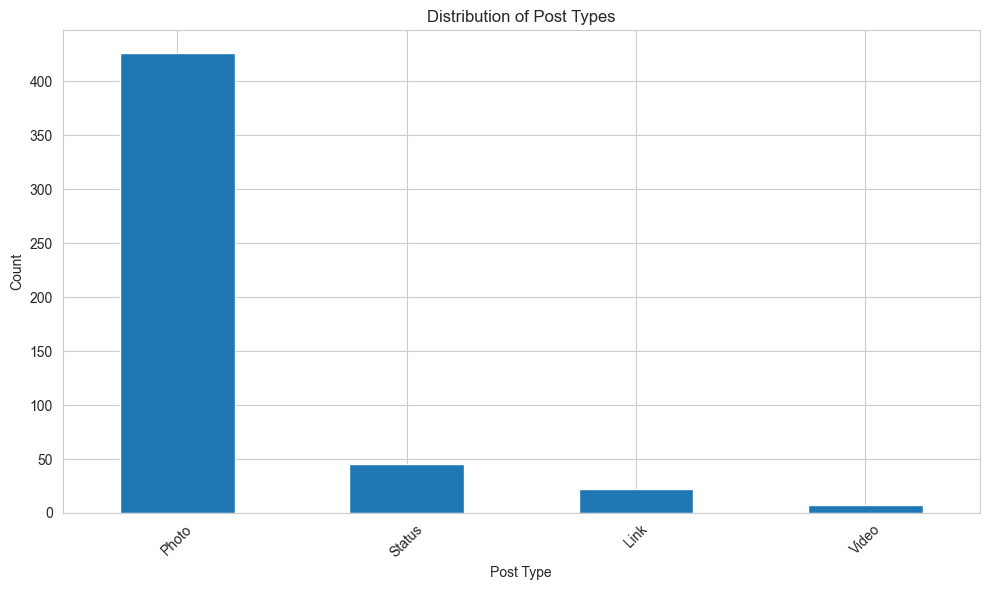

<Figure size 640x480 with 0 Axes>

In [23]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))
df['Type'].value_counts().plot(kind='bar')
plt.title('Distribution of Post Types')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(plots_folder, 'bar_chart_post_types.png')) # Save the plot
plt.show()
plt.clf()

### Visualization 4: Scatter Plot (Relationship between two numeric columns)

I will create a scatter plot to visualize the relationship between 'Lifetime Post Total Reach' and 'Total Interactions'. This can help us observe if posts with higher reach tend to generate more interactions.

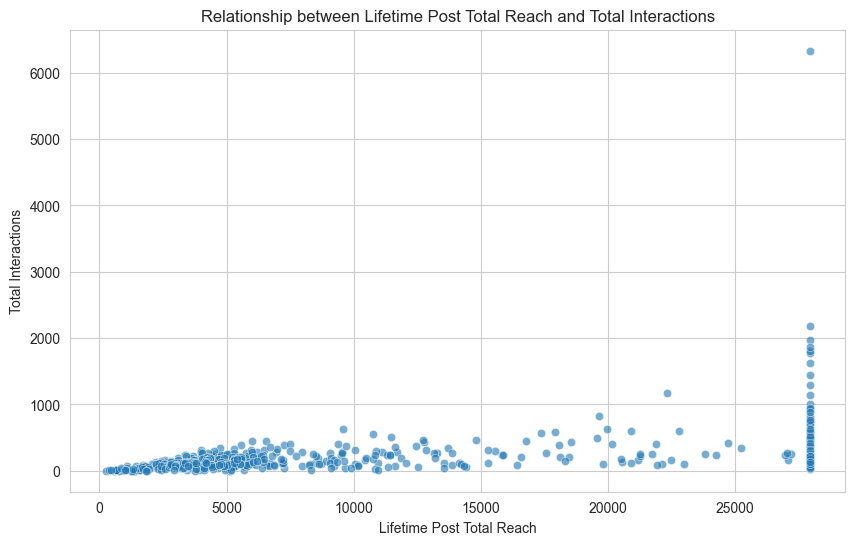

<Figure size 640x480 with 0 Axes>

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Lifetime Post Total Reach'], y=df['Total Interactions'], alpha=0.6)
plt.title('Relationship between Lifetime Post Total Reach and Total Interactions')
plt.xlabel('Lifetime Post Total Reach')
plt.ylabel('Total Interactions')
plt.savefig(os.path.join(plots_folder, 'scatter_plot_reach_interactions.png')) # Save the plot
plt.show()
plt.clf()

### Visualization 5: Chart from `groupby()` Aggregation

I will create a bar chart to show the average total interactions grouped by 'Category'. This will highlight which content categories tend to receive the most engagement on average.

/var/folders/w4/43629hqs3_35tff460hrftd40000gn/T/ipykernel_14790/1007986819.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_interactions_by_category = df.groupby('Category')['Total Interactions'].mean().sort_values(ascending=False)


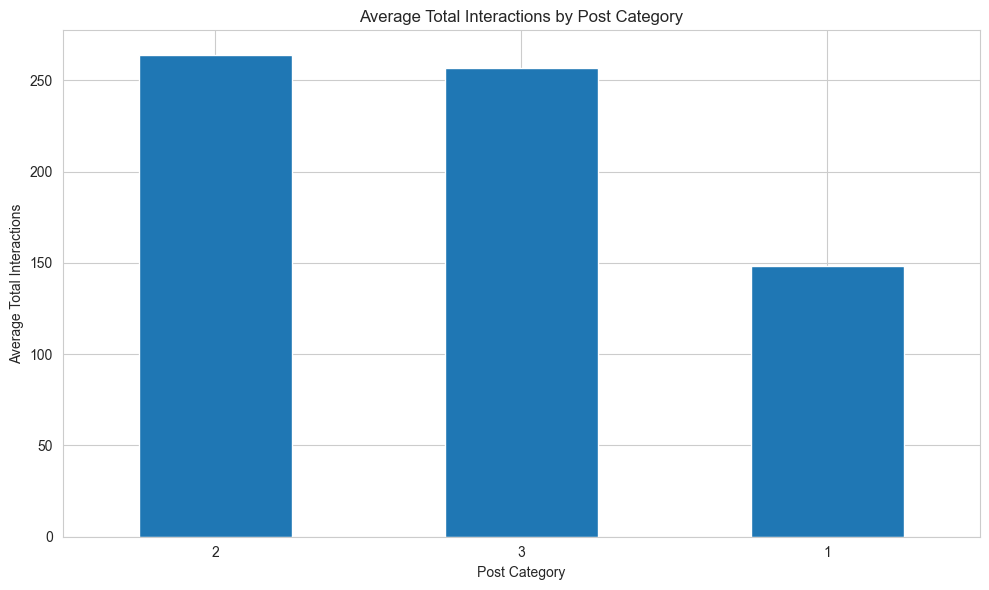

<Figure size 640x480 with 0 Axes>

In [25]:
import matplotlib.pyplot as plt
import os

avg_interactions_by_category = df.groupby('Category')['Total Interactions'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
avg_interactions_by_category.plot(kind='bar')
plt.title('Average Total Interactions by Post Category')
plt.xlabel('Post Category')
plt.ylabel('Average Total Interactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(plots_folder, 'bar_chart_avg_interactions_category.png')) # Save the plot
plt.show()
plt.clf()

In [26]:
import os

plots_folder_path = os.path.join('Plots')

if os.path.exists(plots_folder_path):
    print(f"Contents of '{plots_folder_path}':")
    for item in os.listdir(plots_folder_path):
        print(f"- {item}")
else:
    print(f"Folder '{plots_folder_path}' does not exist.")

Contents of 'Plots':
- histogram_total_interactions.png
- box_plot_reach_impressions.png
- box_plot_reach_impressions_reexecute.png
- bar_chart_post_types.png
- scatter_plot_reach_interactions.png
- bar_chart_avg_interactions_category.png


In [27]:
import os

plots_folder_path = os.path.join('Plots')

if os.path.exists(plots_folder_path):
    print(f"Contents of '{plots_folder_path}':")
    for item in os.listdir(plots_folder_path):
        print(f"- {item}")
else:
    print(f"Folder '{plots_folder_path}' does not exist.")

Contents of 'Plots':
- histogram_total_interactions.png
- box_plot_reach_impressions.png
- box_plot_reach_impressions_reexecute.png
- bar_chart_post_types.png
- scatter_plot_reach_interactions.png
- bar_chart_avg_interactions_category.png


In [28]:
import os

plots_folder_path = os.path.join('Plots')

if os.path.exists(plots_folder_path):
    print(f"Contents of '{plots_folder_path}':")
    for item in os.listdir(plots_folder_path):
        print(f"- {item}")
else:
    print(f"Folder '{plots_folder_path}' does not exist.")

Contents of 'Plots':
- histogram_total_interactions.png
- box_plot_reach_impressions.png
- box_plot_reach_impressions_reexecute.png
- bar_chart_post_types.png
- scatter_plot_reach_interactions.png
- bar_chart_avg_interactions_category.png


In [29]:
import os

plots_folder_path = os.path.join('Plots')

if os.path.exists(plots_folder_path):
    print(f"Contents of '{plots_folder_path}':")
    for item in os.listdir(plots_folder_path):
        print(f"- {item}")
else:
    print(f"Folder '{plots_folder_path}' does not exist.")

Contents of 'Plots':
- histogram_total_interactions.png
- box_plot_reach_impressions.png
- box_plot_reach_impressions_reexecute.png
- bar_chart_post_types.png
- scatter_plot_reach_interactions.png
- bar_chart_avg_interactions_category.png


In [30]:
import os

plots_folder_path = os.path.join('Plots')

if os.path.exists(plots_folder_path):
    for item in os.listdir(plots_folder_path):
        print(f"- {item}")
else:
    print(f"Folder '{plots_folder_path}' does not exist.")

- histogram_total_interactions.png
- box_plot_reach_impressions.png
- box_plot_reach_impressions_reexecute.png
- bar_chart_post_types.png
- scatter_plot_reach_interactions.png
- bar_chart_avg_interactions_category.png


In [31]:
import os

plots_folder_path = os.path.join('Plots')

if os.path.exists(plots_folder_path):
    for item in os.listdir(plots_folder_path):
        print(f"- {item}")
else:
    print(f"Folder '{plots_folder_path}' does not exist.")

- histogram_total_interactions.png
- box_plot_reach_impressions.png
- box_plot_reach_impressions_reexecute.png
- bar_chart_post_types.png
- scatter_plot_reach_interactions.png
- bar_chart_avg_interactions_category.png


In [32]:
import os

plots_folder_path = os.path.join('Plots')

if os.path.exists(plots_folder_path):
    for item in os.listdir(plots_folder_path):
        print(f"- {item}")
else:
    print(f"Folder '{plots_folder_path}' does not exist.")

- histogram_total_interactions.png
- box_plot_reach_impressions.png
- box_plot_reach_impressions_reexecute.png
- bar_chart_post_types.png
- scatter_plot_reach_interactions.png
- bar_chart_avg_interactions_category.png


In [33]:
import os

plots_folder_path = os.path.join('Plots')

if os.path.exists(plots_folder_path):
    print(f"Contents of '{plots_folder_path}':")
    for item in os.listdir(plots_folder_path):
        print(f"- {item}")
else:
    print(f"Folder '{plots_folder_path}' does not exist.")

Contents of 'Plots':
- histogram_total_interactions.png
- box_plot_reach_impressions.png
- box_plot_reach_impressions_reexecute.png
- bar_chart_post_types.png
- scatter_plot_reach_interactions.png
- bar_chart_avg_interactions_category.png


In [34]:
import os

plots_folder_path = os.path.join('Plots')

if os.path.exists(plots_folder_path):
    for item in os.listdir(plots_folder_path):
        print(f"- {item}")
else:
    print(f"Folder '{plots_folder_path}' does not exist.")

- histogram_total_interactions.png
- box_plot_reach_impressions.png
- box_plot_reach_impressions_reexecute.png
- bar_chart_post_types.png
- scatter_plot_reach_interactions.png
- bar_chart_avg_interactions_category.png


In [35]:
query6 = """
SELECT
    post_hour,
    AVG(total_interactions) AS avg_total_interactions
FROM
    facebook_posts
GROUP BY
    post_hour
ORDER BY
    post_hour;
"""
print("Average Total Interactions by Post Hour:")
display(run_query(query6))

Average Total Interactions by Post Hour:


,post_hour,avg_total_interactions
0,1,181.000000
1,2,191.102564
2,3,228.590476
3,4,168.085714
4,5,684.307692
5,6,157.125000
6,7,148.461538
7,8,90.250000
8,9,133.100000
9,10,250.910256


In [36]:
print("Average Total Interactions by Post Hour:")
display(run_query(query6))

Average Total Interactions by Post Hour:


,post_hour,avg_total_interactions
0,1,181.000000
1,2,191.102564
2,3,228.590476
3,4,168.085714
4,5,684.307692
5,6,157.125000
6,7,148.461538
7,8,90.250000
8,9,133.100000
9,10,250.910256


#### Query 3: Monthly Average Total Interactions

This query calculates the average total interactions for posts each month. This can help identify trends or peak performance periods throughout the year.

In [37]:
query3 = """
SELECT
    post_month,
    AVG(total_interactions) AS avg_total_interactions_month
FROM
    facebook_posts
GROUP BY
    post_month
ORDER BY
    post_month;
"""
print("Monthly Average Total Interactions:")
display(run_query(query3))

Monthly Average Total Interactions:


,post_month,avg_total_interactions_month
0,1,160.600000
1,2,242.038462
2,3,97.055556
3,4,217.520000
4,5,256.297297
5,6,157.714286
6,7,328.500000
7,8,225.382353
8,9,278.500000
9,10,182.900000


#### Query 4: Performance Comparison: Paid vs. Unpaid Posts

This query compares the average engagement metrics (likes, shares, comments, total interactions) between paid and unpaid posts. This helps understand the impact of advertising on post performance.

In [38]:
query4 = """
SELECT
    CASE
        WHEN paid = 1 THEN 'Paid'
        ELSE 'Unpaid'
    END AS post_status,
    AVG(like) AS avg_likes,
    AVG(share) AS avg_shares,
    AVG(comment) AS avg_comments,
    AVG(total_interactions) AS avg_total_interactions
FROM
    facebook_posts
GROUP BY
    post_status;
"""
print("Performance Comparison: Paid vs. Unpaid Posts:")
display(run_query(query4))

Performance Comparison: Paid vs. Unpaid Posts:


,post_status,avg_likes,avg_shares,avg_comments,avg_total_interactions
0,Paid,235.647482,32.503597,10.079137,278.230216
1,Unpaid,155.515235,25.157895,6.481994,186.664820


#### Query 5: Top 3 Post Categories by Average Lifetime Engaged Users

This query identifies the top 3 post categories that lead to the highest average number of engaged users over the lifetime of the post. This can inform content strategy.

In [39]:
query5 = """
SELECT
    category,
    AVG(lifetime_engaged_users) AS avg_lifetime_engaged_users
FROM
    facebook_posts
GROUP BY
    category
ORDER BY
    avg_lifetime_engaged_users DESC
LIMIT 3;
"""
print("Top 3 Post Categories by Average Lifetime Engaged Users:")
display(run_query(query5))

Top 3 Post Categories by Average Lifetime Engaged Users:


,category,avg_lifetime_engaged_users
0,2,1138.361538
1,1,851.125581
2,3,833.503226


#### Query 6: Average Total Interactions by Post Hour

This query analyzes how the average total interactions vary by the hour a post was published. This can help determine optimal posting times for maximum engagement.

In [40]:
query6 = """
SELECT
    post_hour,
    AVG(total_interactions) AS avg_total_interactions
FROM
    facebook_posts
GROUP BY
    post_hour
ORDER BY
    post_hour;
"""
print("Average Total Interactions by Post Hour:")
display(run_query(query6))

Average Total Interactions by Post Hour:


,post_hour,avg_total_interactions
0,1,181.000000
1,2,191.102564
2,3,228.590476
3,4,168.085714
4,5,684.307692
5,6,157.125000
6,7,148.461538
7,8,90.250000
8,9,133.100000
9,10,250.910256


In [41]:
import os

current_dir = os.getcwd()
print(current_dir)

df.to_csv(os.path.join(current_dir, "cleaned_facebook_posts.csv"), index=False)

/Users/gauravadarkar/Downloads/AI_Projects/capstone-part1-data-preparation
